In [1]:
import pandas, numpy

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(1/3), 9*(4/3)), 
                            'axes.labelsize':20
                           })
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [3]:
enrichments_file = '/Users/adrian/research/bmcbf/073_bologna/results/enrichment/clusterProfiler_enrichments.tsv'
enrichments_file = '/Users/adrian/research/bmcbf/073_bologna/results/enrichment/clusterProfiler_enrichments.together.tsv'

In [4]:
df = pandas.read_csv(enrichments_file, sep='\t')
df

,Cluster,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
1,D7 vs D0,R-HSA-1474244,Extracellular matrix organization,95/988,321/11214,0.295950,3.359094,13.329398,1.202305e-27,1.625516e-24,1.480733e-24,2006/2192/1311/3908/3690/1634/1404/222663/1513...,95
2,D7 vs D0,R-HSA-1474290,Collagen formation,32/988,90/11214,0.355556,4.035628,8.987228,1.736845e-12,1.174107e-09,1.069531e-09,4015/1295/4314/7373/1301/140766/1514/1281/4017...,32
3,D7 vs D0,R-HSA-1474228,Degradation of the extracellular matrix,39/988,140/11214,0.278571,3.161842,8.000594,4.013961e-11,1.808959e-08,1.647837e-08,2006/1634/222663/1513/9507/1295/4314/7373/1301...,39
4,D7 vs D0,R-HSA-216083,Integrin cell surface interactions,28/988,85/11214,0.329412,3.738890,7.878481,3.355006e-10,1.133992e-07,1.032989e-07,1311/3690/3673/1295/960/6696/1281/3675/3678/12...,28
5,D7 vs D0,R-HSA-3000178,ECM proteoglycans,26/988,76/11214,0.342105,3.882964,7.838427,5.634150e-10,1.376864e-07,1.254228e-07,1311/3908/3690/1634/1404/3673/1281/54829/3910/...,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,D21 vs D7,R-HSA-1650814,Collagen biosynthesis and modifying enzymes,8/247,67/11214,0.119403,5.420992,5.446827,1.050430e-04,4.061661e-03,3.785759e-03,1281/1278/1277/1284/1282/1287/81578/1300,8
121,D21 vs D7,R-HSA-8875878,MET promotes cell motility,6/247,41/11214,0.146341,6.644021,5.433268,2.531208e-04,9.342459e-03,8.707840e-03,1281/1278/1277/3675/3914/10319,6
122,D21 vs D7,R-HSA-3000170,Syndecan interactions,5/247,27/11214,0.185185,8.407557,5.783165,2.702698e-04,9.541699e-03,8.893547e-03,1281/1278/1277/6382/3691,5
123,D21 vs D7,R-HSA-75892,Platelet Adhesion to exposed collagen,4/247,16/11214,0.250000,11.350202,6.217332,3.393280e-04,1.148060e-02,1.070074e-02,1278/1277/8515/7450,4


In [5]:
contrasts = []
for element in df['Cluster']:
    if element not in contrasts:
        contrasts.append(element)

print(contrasts)

['D7 vs D0', 'D28 vs D7', 'D21 vs D7']


In [6]:
terms_to_use = []
top_ten_categories = []
for contrast in contrasts:
    
    print(contrast)
    sub = df[df['Cluster'] == contrast]
    all_observed_gene_lists = []
    contrast_terms = []
    top_ten = []
    
    for index, row in sub.iterrows():
        
        
        genes = row['geneID'].split('/')
        print('\t', row['ID'], row['Description'], len(genes))
        
        # checking the overlap
        overlap = False
        max_overlap = 0
        for element in all_observed_gene_lists:
            intersect = list(set(element) & set(genes))
            relative_intersect = len(intersect)/len(genes)
            #print('\t\t\t intersect is', len(intersect), relative_intersect)
            if max_overlap < relative_intersect:
                max_overlap = relative_intersect
            if relative_intersect > 0.9:
                overlap=True
            
        all_observed_gene_lists.append(genes)

        #print('\t', overlap)
        #print()
        if overlap == False:
            print('\t accepting', row['ID'], row['Description'], 'because overlap is', max_overlap)
            contrast_terms.append(row['ID'])
            if len(contrast_terms) <= 10:
                top_ten.append(row['ID'])
        else:
            print('\t rejecting', row['ID'], row['Description'], 'because overlap is', max_overlap)
        print()

    # end of contrast
    terms_to_use.append(contrast_terms)
    top_ten_categories.append(top_ten)
    print()
    #print(terms_to_use)

D7 vs D0
	 R-HSA-1474244 Extracellular matrix organization 95
	 accepting R-HSA-1474244 Extracellular matrix organization because overlap is 0

	 R-HSA-1474290 Collagen formation 32
	 rejecting R-HSA-1474290 Collagen formation because overlap is 1.0

	 R-HSA-1474228 Degradation of the extracellular matrix 39
	 rejecting R-HSA-1474228 Degradation of the extracellular matrix because overlap is 1.0

	 R-HSA-216083 Integrin cell surface interactions 28
	 rejecting R-HSA-216083 Integrin cell surface interactions because overlap is 1.0

	 R-HSA-3000178 ECM proteoglycans 26
	 rejecting R-HSA-3000178 ECM proteoglycans because overlap is 1.0

	 R-HSA-2022090 Assembly of collagen fibrils and other multimeric structures 23
	 rejecting R-HSA-2022090 Assembly of collagen fibrils and other multimeric structures because overlap is 1.0

	 R-HSA-3000157 Laminin interactions 15
	 rejecting R-HSA-3000157 Laminin interactions because overlap is 1.0

	 R-HSA-1566948 Elastic fibre formation 18
	 rejecting R

In [7]:
for content in terms_to_use:
    print(len(content), content)

print()

for top_ten in top_ten_categories:
    print(len(top_ten), top_ten)

union_list = list(set(item for sublist in top_ten_categories for item in sublist))

print()

print(len(union_list), union_list)

31 ['R-HSA-1474244', 'R-HSA-6785807', 'R-HSA-3560782', 'R-HSA-381426', 'R-HSA-114608', 'R-HSA-9694614', 'R-HSA-198725', 'R-HSA-76002', 'R-HSA-191273', 'R-HSA-9925563', 'R-HSA-1630316', 'R-HSA-202733', 'R-HSA-3781865', 'R-HSA-166520', 'R-HSA-9820960', 'R-HSA-6783589', 'R-HSA-449147', 'R-HSA-112316', 'R-HSA-500792', 'R-HSA-373760', 'R-HSA-418990', 'R-HSA-9856532', 'R-HSA-140877', 'R-HSA-5576891', 'R-HSA-397014', 'R-HSA-5668914', 'R-HSA-416700', 'R-HSA-2162123', 'R-HSA-9855142', 'R-HSA-446728', 'R-HSA-9009391']
16 ['R-HSA-3000157', 'R-HSA-8874081', 'R-HSA-3000178', 'R-HSA-9925563', 'R-HSA-3000171', 'R-HSA-2173782', 'R-HSA-1474244', 'R-HSA-9734767', 'R-HSA-6806834', 'R-HSA-186797', 'R-HSA-6809371', 'R-HSA-69273', 'R-HSA-156711', 'R-HSA-6791312', 'R-HSA-3560782', 'R-HSA-419037']
7 ['R-HSA-1474244', 'R-HSA-2173782', 'R-HSA-9648895', 'R-HSA-9925563', 'R-HSA-9734767', 'R-HSA-176974', 'R-HSA-9671793']

10 ['R-HSA-1474244', 'R-HSA-6785807', 'R-HSA-3560782', 'R-HSA-381426', 'R-HSA-114608', 'R-HSA

[['R-HSA-1474244', 'R-HSA-6785807', 'R-HSA-3560782', 'R-HSA-381426', 'R-HSA-114608', 'R-HSA-9694614', 'R-HSA-198725', 'R-HSA-76002', 'R-HSA-191273', 'R-HSA-9925563', 'R-HSA-1630316', 'R-HSA-202733', 'R-HSA-3781865', 'R-HSA-166520', 'R-HSA-9820960', 'R-HSA-6783589', 'R-HSA-449147', 'R-HSA-112316', 'R-HSA-500792', 'R-HSA-373760', 'R-HSA-418990', 'R-HSA-9856532', 'R-HSA-140877', 'R-HSA-5576891', 'R-HSA-397014', 'R-HSA-5668914', 'R-HSA-416700', 'R-HSA-2162123', 'R-HSA-9855142', 'R-HSA-446728', 'R-HSA-9009391'], ['R-HSA-3000157', 'R-HSA-8874081', 'R-HSA-3000178', 'R-HSA-9925563', 'R-HSA-3000171', 'R-HSA-2173782', 'R-HSA-1474244', 'R-HSA-9734767', 'R-HSA-6806834', 'R-HSA-186797', 'R-HSA-6809371', 'R-HSA-69273', 'R-HSA-156711', 'R-HSA-6791312', 'R-HSA-3560782', 'R-HSA-419037'], ['R-HSA-1474244', 'R-HSA-2173782', 'R-HSA-9648895', 'R-HSA-9925563', 'R-HSA-9734767', 'R-HSA-176974', 'R-HSA-9671793']]
-1 R-HSA-1474244
-2 R-HSA-6785807
-3 R-HSA-3560782
-4 R-HSA-381426
-5 R-HSA-114608
-6 R-HSA-969461

/var/folders/j2/645ctp717nv8rwbn2dsccyxh0000gn/T/ipykernel_3761/4212696362.py:50: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  matplotlib.pyplot.tight_layout()


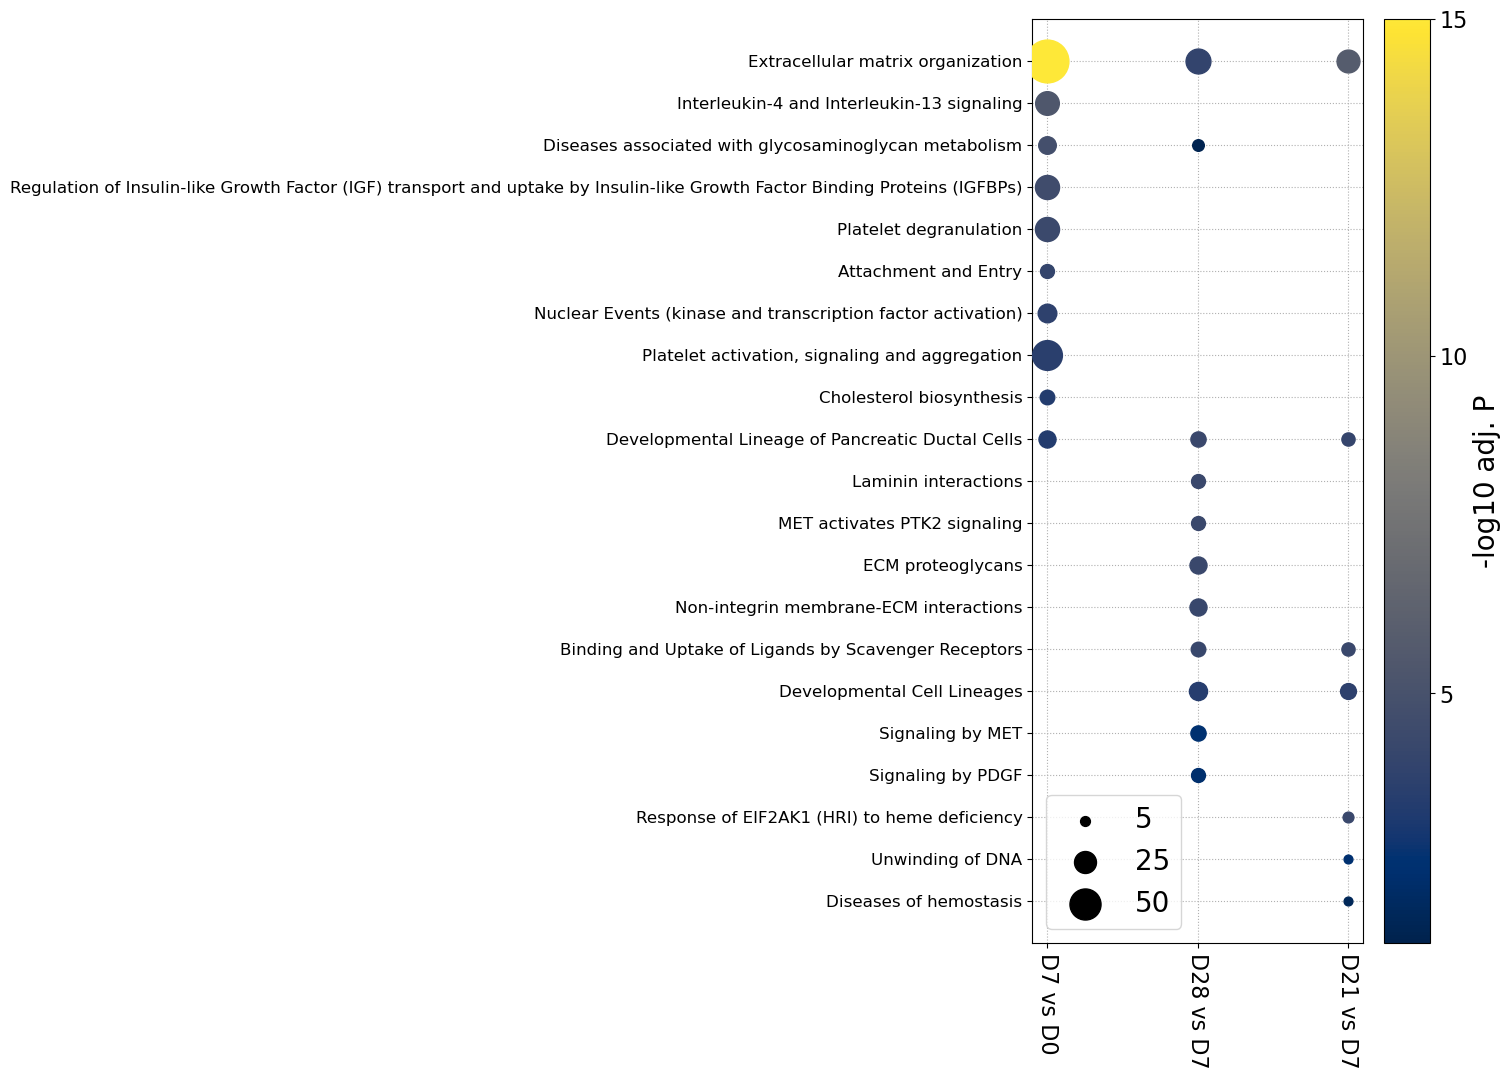

In [13]:
terms_used_so_far = {}
depth = 0
print(terms_to_use)
factor_size_circles = 10
for i in range(len(terms_to_use)):
    for j in range(len(terms_to_use[i])):
        element = terms_to_use[i][j]

        if element in union_list:
        
            if element in terms_used_so_far.keys():
                location = terms_used_so_far[element]
            else:
                depth = depth - 1
                location = depth
    
            # define color
            adjp = -numpy.log10(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['p.adjust'].values[0])
            #print(element, adjp)
    
            # define size
            thesize = int(df[(df['ID'] == element) & (df['Cluster'] == contrasts[i])]['GeneRatio'].values[0].split('/')[0])
            
            # make a point        
            matplotlib.pyplot.scatter(i, location, s=thesize*factor_size_circles, c=adjp, zorder=9999, cmap='cividis', vmin=-numpy.log10(0.05), vmax=15)
            terms_used_so_far[element] = location
            print(location, element)


matplotlib.pyplot.colorbar(label='-log10 adj. P', ticks=[5, 10, 15])

# close the figure
a = []; b = []
for element in terms_used_so_far.keys():
    description = list(df[df['ID'] == element]['Description'].values)[0]
    a.append(description)
    b.append(terms_used_so_far[element])

for area in factor_size_circles*numpy.array([5, 25, 50]):
    matplotlib.pyplot.scatter([], [], c='black', edgecolor=None, s=area, label=str(int(area/factor_size_circles)))
matplotlib.pyplot.legend(loc=3)

matplotlib.pyplot.yticks(b, a, fontsize=12)
matplotlib.pyplot.xticks(list(range(len(contrasts))), 
                         contrasts, 
                         rotation=-90)

#matplotlib.pyplot.ylim(-40.75, -0.25)
matplotlib.pyplot.grid(ls=':')
matplotlib.pyplot.tight_layout()

#matplotlib.pyplot.show()
matplotlib.pyplot.savefig('enrichment.svg')

In [9]:
list(range(len(contrasts)))

[0, 1, 2]

In [10]:
len(contrasts)

3